# 04. 심화 모델링 — RandomForest 튜닝 / Lasso 피처 선택 / K-Fold / VIF / XGBoost·LightGBM

`03_model_comparison.ipynb`의 실행 결과(1차 보고서, `reports/01_model_comparison_report.md`)에서
발견된 개선 여지들을 실제로 구현하고 검증하는 노트북입니다. **03 노트북은 이미 1차 보고서의
근거 자료이므로 수정하지 않고 그대로 보존**하며, 이 노트북은 03이 만들어 둔 산출물
(`data_processed/*_skew_corrected.csv`, `checkpoints/final_minmax_scaler.joblib`,
`checkpoints/{ridge,lasso,gradient_boosting}.joblib` 등)을 재사용해 아래 6가지를 진행합니다.

1. **RandomForest `max_depth` 튜닝** — 03에서는 `max_depth`를 탐색하지 않아 심하게 과적합
   (Train R²=0.79 vs Test R²=-0.315)되었던 문제를 그리드서치로 보완합니다.
2. **Lasso 선택 피처만으로 재학습** — 03의 Lasso가 0으로 축소하지 않은 피처만 사용해
   Ridge/RandomForest를 다시 학습하고 전체 피처 사용 대비 성능을 비교합니다.
3. **XGBoost / LightGBM 추가** — 정규화가 내장된 부스팅 모델을 작은 표본에 맞는 설정으로
   시도해, 03의 GradientBoosting이 겪었던 문제(2번째 트리부터 성능 악화)를 완화할 수 있는지
   확인합니다.
4. **K-Fold 교차검증(안정성 검증)** — 기존 Validation 기반 하이퍼파라미터 탐색 방식은
   그대로 유지하되, 최종 후보 모델들의 성능이 fold 구성에 따라 얼마나 흔들리는지 병행
   검증합니다.
5. **VIF 기반 다중공선성 재점검** — 03에서 LinearRegression 계수 하나가 비정상적으로
   커졌던(~1.6×10¹³) 현상의 원인을 pairwise 상관계수보다 엄밀한 VIF로 재확인합니다.
6. **Ridge/Lasso/GradientBoosting 피처 중요도 PNG 저장** — 03에서 셀 출력으로만 남아있던
   그래프를 파일로 저장합니다.

## 프로젝트 지침 체크리스트

- [x] 수정 전 항상 확인: 이 노트북은 사용자 승인(AskUserQuestion 답변: 새 노트북 04 생성,
      라이브러리 전부 설치 + requirements 갱신, K-Fold는 병행 검증용)을 받은 뒤 작성했습니다.
- [x] 함수에는 어떤 함수인지 설명하는 주석(docstring)을 달았습니다 (`src/training_utils.py`
      섹션 11 참고).
- [x] 모든 학습에 진행상황(tqdm progress bar)을 표시합니다.
- [x] 중간에 끊겨도 이어서 학습할 수 있도록 체크포인트(재개 가능한 학습) 기능을 사용합니다.
- [x] Test 세트는 03에서 이미 계산된 7개 모델의 결과는 CSV에서 그대로 재사용하고, 이 노트북에서
      새로 학습하는 모델들에 대해서만 "최종 테스트 비교" 셀에서 **단 한 번** 사용합니다.

## 새로 필요한 라이브러리

이 노트북은 `xgboost`, `lightgbm`, `statsmodels`(VIF 계산용)를 사용합니다. 아래 셀에서
import가 실패하면 가상환경에 설치가 안 된 것이므로, 터미널에서 다음을 실행하세요.

```
pip install -r requirements.txt
```

In [1]:
# ---- 0. 환경 설정 ----
import os
import sys
import json
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# src/training_utils.py 를 import 하기 위해 경로 추가
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC_DIR = os.path.join(PROJECT_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import training_utils as tu

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
DATA_DIR = os.path.join(PROJECT_ROOT, "data_processed")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
FIGURE_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

tu.set_korean_font()
print("환경 설정 완료. RANDOM_STATE =", RANDOM_STATE)

[한글 폰트] 'NanumGothicOTF' 적용 완료.
환경 설정 완료. RANDOM_STATE = 42


## 1. 데이터 로드 — 02의 skew 보정 데이터 + 03의 MinMaxScaler 재사용

02 노트북이 만든 `X_train/X_val/X_test_skew_corrected.csv`(Unnamed 컬럼 제외, 다중공선성
제거 및 Yeo-Johnson 변환 완료)를 불러오고, **03에서 이미 train에만 fit된**
`final_minmax_scaler.joblib`을 그대로 `transform()`만 적용합니다. 새로 `fit()`하지 않고
03이 학습해 둔 스케일러를 재사용하는 이유는, 이 노트북에서 학습하는 새 모델들을 03의
7개 모델과 **완전히 동일한 전처리 결과** 위에서 비교하기 위함입니다 (전처리가 다르면
성능 차이가 모델 때문인지 전처리 때문인지 구분할 수 없습니다).

In [2]:
# ---- 1. 데이터 로드 ----
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_skew_corrected.csv"), index_col=0)
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val_skew_corrected.csv"), index_col=0)
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_skew_corrected_DO_NOT_OPEN.csv"), index_col=0)

y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"), index_col=0).iloc[:, 0]
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv"), index_col=0).iloc[:, 0]
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test_DO_NOT_OPEN.csv"), index_col=0).iloc[:, 0]

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "train/val/test 컬럼 구성이 다릅니다."

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"피처 수: {X_train.shape[1]}개")

X_train: (108, 26), X_val: (14, 26), X_test: (14, 26)
피처 수: 26개


In [3]:
# ---- 1-2. 03이 학습해 둔 MinMaxScaler를 재사용 (train에만 fit된 것을 transform만) ----
scaler = joblib.load(os.path.join(CHECKPOINT_DIR, "final_minmax_scaler.joblib"))

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
# X_test는 "최종 테스트 비교" 섹션에서 새 모델을 평가할 때만 transform 한다 (누수 방지 원칙 유지)

print("MinMaxScaler 재사용 완료 (train/val transform 적용, test는 최종 평가 시점까지 보류)")
X_train_scaled.describe().T[["min", "max"]].head()

MinMaxScaler 재사용 완료 (train/val transform 적용, test는 최종 평가 시점까지 보류)


,min,max
건조 1존 OP_min,0.0,1.000000e+00
건조 2존 OP_min,0.0,1.000000e+00
건조로 온도 1 Zone_min,0.0,1.000000e+00
건조로 온도 2 Zone_min,0.0,1.221245e-15
세정기_min,0.0,1.000000e+00


## 2. RandomForest `max_depth` 튜닝

03에서는 RandomForest를 `train_random_forest_with_checkpoint()`로 학습하면서 트리 개수
(`n_estimators`)만 체크포인트 방식으로 늘려갔고 `max_depth`는 탐색하지 않았습니다
(기본값 `None` = 무제한). 그 결과 Train R²=0.7867인데 Test R²=-0.3150으로 전체 모델 중
최하위를 기록할 만큼 심하게 과적합했습니다.

여기서는 `training_utils.grid_search_by_val_checkpoint()`로 여러 `max_depth` 후보에 대해
각각 `train_random_forest_with_checkpoint()`(체크포인트 재개 가능, tqdm 진행률 표시)를
실행하고, Validation R²가 가장 좋은 `max_depth`를 선택합니다. 후보마다 별도의 체크포인트
파일을 사용하므로 노트북이 중간에 끊겨도 이미 끝난 후보는 다시 학습하지 않습니다.

In [4]:
# ---- 2. RandomForest max_depth 그리드서치 (체크포인트 재개 가능) ----
rf_max_depth_grid = [{"max_depth": d} for d in [2, 3, 4, 5, 6, 8, 10, None]]

rf_tuned_result = tu.grid_search_by_val_checkpoint(
    tu.train_random_forest_with_checkpoint,
    rf_max_depth_grid,
    X_train_scaled, y_train, X_val_scaled, y_val,
    checkpoint_dir=CHECKPOINT_DIR,
    base_name="rf_maxdepth",
    train_fn_kwargs=dict(
        max_estimators=300, estimators_per_step=20,
        checkpoint_every_steps=3, patience_steps=5,
        random_state=RANDOM_STATE,
    ),
)

rf_tuned_model = rf_tuned_result["best_model"]
rf_tuned_best_depth = rf_tuned_result["best_params"]["max_depth"]
print("최적 max_depth:", rf_tuned_best_depth)
rf_tuned_result["results"]

rf_maxdepth 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/8 [00:00<?, ?it/s]

RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 10 (트리 220개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 8 (트리 180개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


...

RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 8 (트리 180개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 9 (트리 200개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
최적 max_depth: 6


,max_depth,train_R2,val_R2,val_RMSE,val_MAE
0,6.0,0.748223,-0.155225,0.028907,0.022644
1,3.0,0.611028,-0.200263,0.029465,0.022763
2,10.0,0.769088,-0.312243,0.030809,0.024415
3,4.0,0.686516,-0.335000,0.031075,0.023961
4,8.0,0.769912,-0.342531,0.031163,0.024618
5,NaN,0.786717,-0.354402,0.031300,0.024186
6,2.0,0.477350,-0.369765,0.031477,0.024147
7,5.0,0.716360,-0.404065,0.031869,0.024292


In [5]:
# ---- 2-1. 튜닝된 RandomForest 학습곡선 시각화 + 03 대비 개선 확인 ----
fig = tu.plot_training_curve(
    rf_tuned_result["best_history"],
    title=f"RandomForest 학습 곡선 (max_depth={rf_tuned_best_depth}, 튜닝 후)",
    xlabel="트리 추가 step",
)
fig.savefig(os.path.join(FIGURE_DIR, "21_rf_maxdepth_tuned_training_curve.png"), dpi=150)
plt.show()

rf_tuned_train_metrics = tu.evaluate_regression(y_train, rf_tuned_model.predict(X_train_scaled))
rf_tuned_val_metrics = tu.evaluate_regression(y_val, rf_tuned_model.predict(X_val_scaled))

print("[03의 RandomForest (max_depth=None)] Train R2=0.7867, Val R2=-0.3544 (참고용 하드코딩 값)")
print(f"[04 튜닝된 RandomForest (max_depth={rf_tuned_best_depth})] "
      f"Train R2={rf_tuned_train_metrics['R2']:.4f}, Val R2={rf_tuned_val_metrics['R2']:.4f}")

<Figure size 800x500 with 1 Axes>

[03의 RandomForest (max_depth=None)] Train R2=0.7867, Val R2=-0.3544 (참고용 하드코딩 값)
[04 튜닝된 RandomForest (max_depth=6)] Train R2=0.7482, Val R2=-0.1552


## 3. Lasso가 선택한 피처만으로 재학습

03의 Lasso(alpha≈0.00068)는 26개 피처 중 19개의 계수를 정확히 0으로 축소했습니다
(=7개 피처만 실질적으로 사용). 이 절에서는 03이 저장해 둔 `checkpoints/lasso.joblib`을
불러와 0이 아닌 피처만 골라낸 뒤, 그 피처만으로 Ridge와 (섹션 2에서 찾은 최적
`max_depth`의) RandomForest를 다시 학습해 전체 피처를 쓴 03의 결과와 비교합니다.

In [6]:
# ---- 3. 03의 Lasso 모델을 불러와 0이 아닌 계수를 가진 피처만 선택 ----
lasso_model_03 = joblib.load(os.path.join(CHECKPOINT_DIR, "lasso.joblib"))
lasso_selected_features = tu.select_nonzero_lasso_features(
    lasso_model_03, X_train_scaled.columns.tolist()
)
print(f"Lasso가 선택한 피처 수: {len(lasso_selected_features)} / {X_train_scaled.shape[1]}")
print(lasso_selected_features)

X_train_sub = X_train_scaled[lasso_selected_features]
X_val_sub = X_val_scaled[lasso_selected_features]

Lasso가 선택한 피처 수: 7 / 26
['건조 1존 OP_min', '건조로 온도 1 Zone_min', '세정기_max', '소입2존 OP_max', '소입3존 OP_max', '소입4존 OP_max', '소입로 CP 값_max']


In [7]:
# ---- 3-1. Lasso 선택 피처만으로 Ridge 재학습 (val 기준 alpha 그리드서치) ----
ridge_subset_result = tu.grid_search_by_val(
    Ridge, [{"alpha": a} for a in np.logspace(-3, 3, 13)],
    X_train_sub, y_train, X_val_sub, y_val,
)
ridge_subset_model = ridge_subset_result["best_model"]
print("Lasso 피처 서브셋 - Ridge 최적 alpha:", ridge_subset_result["best_params"])
ridge_subset_result["results"].head()

Ridge 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

Lasso 피처 서브셋 - Ridge 최적 alpha: {'alpha': 10.0}


,alpha,train_R2,val_R2,val_RMSE,val_MAE
0,10.000000,0.070040,0.015417,0.026687,0.019328
1,31.622777,0.030872,0.011605,0.026738,0.019985
2,100.000000,0.011221,0.004125,0.026839,0.020336
3,316.227766,0.003727,0.000369,0.026890,0.020462
4,1000.000000,0.001198,-0.001007,0.026908,0.020503


In [8]:
# ---- 3-2. Lasso 선택 피처만으로 RandomForest 재학습 (섹션 2의 최적 max_depth 사용) ----
cm_rf_subset = tu.CheckpointManager(CHECKPOINT_DIR, name="rf_lasso_subset")
rf_subset_result = tu.train_random_forest_with_checkpoint(
    X_train_sub, y_train, X_val_sub, y_val, cm_rf_subset,
    max_estimators=300, estimators_per_step=20,
    checkpoint_every_steps=3, patience_steps=5,
    random_state=RANDOM_STATE, max_depth=rf_tuned_best_depth,
)
rf_subset_model = rf_subset_result["model"]

ridge_subset_val = tu.evaluate_regression(y_val, ridge_subset_model.predict(X_val_sub))
rf_subset_val = tu.evaluate_regression(y_val, rf_subset_model.predict(X_val_sub))

print("=== 전체 피처(26개) vs Lasso 선택 피처(%d개) Val R2 비교 ===" % len(lasso_selected_features))
print(f"Ridge   : 전체 피처 Val R2=0.0124 (03 결과, 참고용 하드코딩)  vs  서브셋 Val R2={ridge_subset_val['R2']:.4f}")
print(f"RandomForest(튜닝) : 전체 피처 Val R2={rf_tuned_val_metrics['R2']:.4f}  vs  서브셋 Val R2={rf_subset_val['R2']:.4f}")

RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 120개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
=== 전체 피처(26개) vs Lasso 선택 피처(7개) Val R2 비교 ===
Ridge   : 전체 피처 Val R2=0.0124 (03 결과, 참고용 하드코딩)  vs  서브셋 Val R2=0.0154
RandomForest(튜닝) : 전체 피처 Val R2=-0.1552  vs  서브셋 Val R2=-0.8978


## 4. XGBoost — 정규화 내장 부스팅

03의 `GradientBoostingRegressor`는 108건의 작은 학습 표본 때문에 2번째 트리부터 Val
손실이 악화되어(`best_n_estimators=1`) 사실상 부스팅의 이점을 살리지 못했습니다.
XGBoost는 L1/L2 정규화, 트리 최대 깊이 제한, 컬럼/행 서브샘플링 등을 함께 조절할 수
있어 작은 표본에서도 더 안정적으로 부스팅할 가능성이 있습니다.

`training_utils.train_xgboost_with_checkpoint()`(신규 함수, 섹션 11)로 `max_depth`/
`learning_rate` 조합 몇 가지를 `grid_search_by_val_checkpoint()`로 탐색합니다. 트리를
작게(`max_depth`≤3), 학습률을 낮게 잡아 과적합을 억제하는 방향으로 그리드를 구성했습니다.

In [9]:
# ---- 4. XGBoost 하이퍼파라미터 탐색 (체크포인트 재개 가능) ----
xgb_param_grid = [
    {"max_depth": d, "learning_rate": lr}
    for d in [2, 3]
    for lr in [0.03, 0.05, 0.1]
]

xgb_result = tu.grid_search_by_val_checkpoint(
    tu.train_xgboost_with_checkpoint,
    xgb_param_grid,
    X_train_scaled, y_train, X_val_scaled, y_val,
    checkpoint_dir=CHECKPOINT_DIR,
    base_name="xgboost",
    train_fn_kwargs=dict(
        max_estimators=300, estimators_per_step=15,
        checkpoint_every_steps=3, patience_steps=5,
        random_state=RANDOM_STATE,
        reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
    ),
)

xgb_model = xgb_result["best_model"]
print("XGBoost 최적 하이퍼파라미터:", xgb_result["best_params"])
xgb_result["results"].head()

xgboost 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/6 [00:00<?, ?it/s]

XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


...

XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
XGBoost 최적 하이퍼파라미터: {'max_depth': 3, 'learning_rate': 0.03}


,max_depth,learning_rate,train_R2,val_R2,val_RMSE,val_MAE
0,3,0.03,0.228814,-0.014779,0.027093,0.020819
1,2,0.03,0.177684,-0.050493,0.027566,0.020984
2,3,0.05,0.351772,-0.082526,0.027983,0.021390
3,2,0.05,0.262182,-0.096122,0.028158,0.021693
4,3,0.10,0.550363,-0.317116,0.030866,0.023696


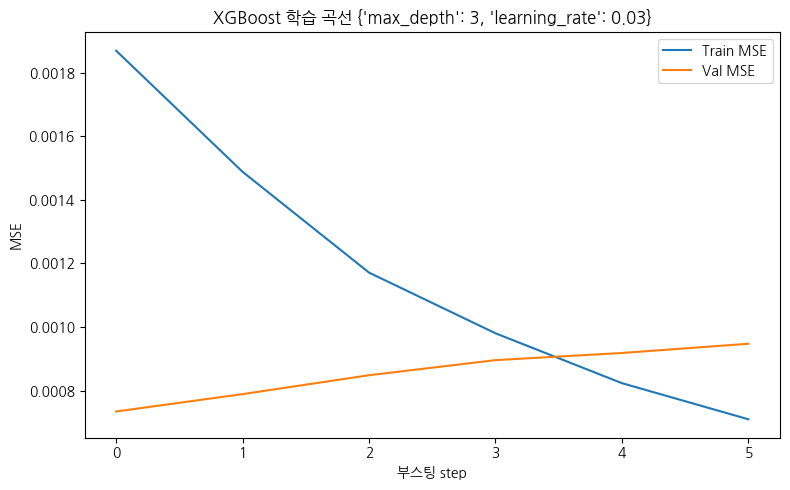

XGBoost Val R2=-0.0148 (참고: 03 GradientBoosting Val R2=-0.0088)


In [10]:
# ---- 4-1. XGBoost 학습곡선 시각화 ----
fig = tu.plot_training_curve(
    xgb_result["best_history"],
    title=f"XGBoost 학습 곡선 {xgb_result['best_params']}",
    xlabel="부스팅 step",
)
fig.savefig(os.path.join(FIGURE_DIR, "22_xgboost_training_curve.png"), dpi=150)
plt.show()

xgb_val_metrics = tu.evaluate_regression(y_val, xgb_model.predict(X_val_scaled))
print(f"XGBoost Val R2={xgb_val_metrics['R2']:.4f} "
      f"(참고: 03 GradientBoosting Val R2=-0.0088)")

## 5. LightGBM — leaf-wise 부스팅

LightGBM은 leaf-wise 트리 성장 방식으로 XGBoost보다 빠르게 학습되며, `min_child_samples`
(리프 노드 최소 샘플 수)로 작은 표본에서의 과적합을 직접 제어할 수 있습니다. 표본이
108건으로 작으므로 `min_child_samples`를 크게(5~10) 설정해 트리가 지나치게 세분화되는
것을 막는 방향으로 그리드를 구성했습니다.

In [11]:
# ---- 5. LightGBM 하이퍼파라미터 탐색 (체크포인트 재개 가능) ----
lgb_param_grid = [
    {"max_depth": d, "learning_rate": lr, "min_child_samples": mcs}
    for d in [2, 3]
    for lr in [0.05, 0.1]
    for mcs in [5, 10]
]

lgb_result = tu.grid_search_by_val_checkpoint(
    tu.train_lightgbm_with_checkpoint,
    lgb_param_grid,
    X_train_scaled, y_train, X_val_scaled, y_val,
    checkpoint_dir=CHECKPOINT_DIR,
    base_name="lightgbm",
    train_fn_kwargs=dict(
        max_estimators=300, estimators_per_step=15,
        checkpoint_every_steps=3, patience_steps=5,
        random_state=RANDOM_STATE,
        reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
    ),
)

lgb_model = lgb_result["best_model"]
print("LightGBM 최적 하이퍼파라미터:", lgb_result["best_params"])
lgb_result["results"].head()

lightgbm 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/8 [00:00<?, ?it/s]

LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 7 (트리 120개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


  File "c:\Users\iymg1\Documents\pre-kamp2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]

...

LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
LightGBM 최적 하이퍼파라미터: {'max_depth': 2, 'learning_rate': 0.1, 'min_child_samples': 5}


,max_depth,learning_rate,min_child_samples,train_R2,val_R2,val_RMSE,val_MAE
0,2,0.10,5,0.638685,0.014053,0.026705,0.018641
1,2,0.05,10,0.450917,-0.057057,0.027652,0.019101
2,2,0.10,10,0.499380,-0.064451,0.027748,0.019853
3,3,0.05,5,0.240001,-0.071239,0.027836,0.021117
4,3,0.05,10,0.181914,-0.074864,0.027883,0.020811


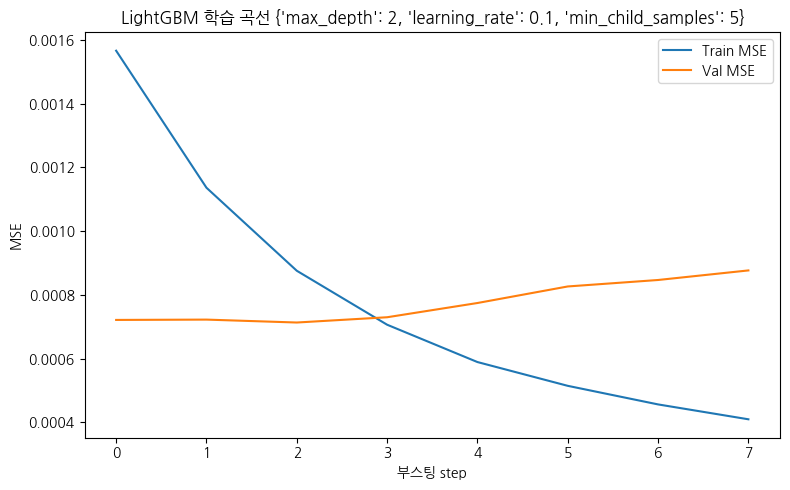

LightGBM Val R2=0.0141 (참고: 03 GradientBoosting Val R2=-0.0088)


In [12]:
# ---- 5-1. LightGBM 학습곡선 시각화 ----
fig = tu.plot_training_curve(
    lgb_result["best_history"],
    title=f"LightGBM 학습 곡선 {lgb_result['best_params']}",
    xlabel="부스팅 step",
)
fig.savefig(os.path.join(FIGURE_DIR, "23_lightgbm_training_curve.png"), dpi=150)
plt.show()

lgb_val_metrics = tu.evaluate_regression(y_val, lgb_model.predict(X_val_scaled))
print(f"LightGBM Val R2={lgb_val_metrics['R2']:.4f} "
      f"(참고: 03 GradientBoosting Val R2=-0.0088)")

## 6. K-Fold 교차검증 — 안정성 검증 (하이퍼파라미터 탐색 방식은 유지)

01~03과 마찬가지로 하이퍼파라미터는 여전히 **Validation set 기준**으로 선택합니다
(위 섹션 2·4·5에서 이미 완료). 다만 Val set이 14건뿐이라 R²의 추정 분산이 클 수
있으므로, 지금까지 찾은 최종 후보들(03의 Lasso/Ridge, 섹션 2의 튜닝된 RandomForest,
섹션 4의 XGBoost, 섹션 5의 LightGBM)에 대해 **Train+Val을 합친 데이터로 5-Fold
교차검증**을 수행해 "이 성능이 fold 구성을 바꿔도 유지되는지" 안정성만 확인합니다.
(Test set은 여기서도 사용하지 않습니다.)

In [13]:
# ---- 6. K-Fold 안정성 검증 대상 후보 구성 ----
X_trainval_scaled = pd.concat([X_train_scaled, X_val_scaled], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

ridge_model_03 = joblib.load(os.path.join(CHECKPOINT_DIR, "ridge.joblib"))

kfold_candidates = {
    "Lasso (03)": dict(
        model_class=Lasso,
        params={"alpha": lasso_model_03.alpha},
        fixed_params={"max_iter": 20000},
    ),
    "Ridge (03)": dict(
        model_class=Ridge,
        params={"alpha": ridge_model_03.alpha},
        fixed_params={},
    ),
    f"RandomForest (04, max_depth={rf_tuned_best_depth})": dict(
        model_class=RandomForestRegressor,
        params={"max_depth": rf_tuned_best_depth, "n_estimators": rf_tuned_model.n_estimators},
        fixed_params={"n_jobs": -1},
    ),
    f"XGBoost (04, {xgb_result['best_params']})": dict(
        model_class=XGBRegressor,
        params={**xgb_result["best_params"], "n_estimators": xgb_model.n_estimators},
        fixed_params={"reg_alpha": 0.1, "reg_lambda": 1.0, "subsample": 0.8, "colsample_bytree": 0.8},
    ),
    f"LightGBM (04, {lgb_result['best_params']})": dict(
        model_class=LGBMRegressor,
        params={**lgb_result["best_params"], "n_estimators": lgb_model.n_estimators},
        fixed_params={"verbose": -1, "reg_alpha": 0.1, "reg_lambda": 1.0, "subsample": 0.8, "colsample_bytree": 0.8},
    ),
}
print("K-Fold 안정성 검증 대상:", list(kfold_candidates.keys()))

K-Fold 안정성 검증 대상: ['Lasso (03)', 'Ridge (03)', 'RandomForest (04, max_depth=6)', "XGBoost (04, {'max_depth': 3, 'learning_rate': 0.03})", "LightGBM (04, {'max_depth': 2, 'learning_rate': 0.1, 'min_child_samples': 5})"]


In [14]:
# ---- 6-1. 후보별 5-Fold 교차검증 실행 ----
kfold_summary_rows = []
kfold_detail = {}

for name, cfg in kfold_candidates.items():
    result = tu.kfold_stability_check(
        cfg["model_class"], cfg["params"], X_trainval_scaled, y_trainval,
        n_splits=5, random_state=RANDOM_STATE, fixed_params=cfg["fixed_params"],
    )
    kfold_detail[name] = result
    kfold_summary_rows.append({
        "model": name,
        "kfold_mean_R2": result["mean_R2"], "kfold_std_R2": result["std_R2"],
        "kfold_mean_RMSE": result["mean_RMSE"], "kfold_std_RMSE": result["std_RMSE"],
    })

kfold_summary_df = pd.DataFrame(kfold_summary_rows).sort_values("kfold_mean_R2", ascending=False)
kfold_summary_df.to_csv(os.path.join(DATA_DIR, "kfold_stability_results.csv"), index=False)
kfold_summary_df

Lasso K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

Ridge K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

RandomForestRegressor K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

XGBRegressor K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

LGBMRegressor K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

,model,kfold_mean_R2,kfold_std_R2,kfold_mean_RMSE,kfold_std_RMSE
1,Ridge (03),-0.155050,0.201743,0.040944,0.027417
3,"XGBoost (04, {'max_depth': 3, 'learning_rate':...",-0.193031,0.237211,0.041512,0.027708
0,Lasso (03),-0.217849,0.348417,0.041117,0.026569
4,"LightGBM (04, {'max_depth': 2, 'learning_rate'...",-0.373318,0.451816,0.043095,0.026944
2,"RandomForest (04, max_depth=6)",-1.592654,1.465510,0.051570,0.020224


## 7. VIF(분산팽창지수) 기반 다중공선성 재점검

03의 LinearRegression 계수 중 하나("건조로 온도 2 Zone_min")가 약 1.6×10¹³으로 비정상적으로
컸던 현상은 02에서 사용한 pairwise 상관계수(|r|≥0.8) 기준 제거만으로는 걸러지지 않는
**3개 이상 변수 간 선형결합**이 남아있을 가능성을 시사합니다. `training_utils.compute_vif()`
(신규 함수, 섹션 11)로 train 데이터의 VIF를 계산해 이 가설을 정량적으로 확인합니다.

In [15]:
# ---- 7. VIF 계산 (train 데이터만 사용) ----
vif_df = tu.compute_vif(X_train_scaled, high_vif_threshold=10.0)
vif_df.to_csv(os.path.join(DATA_DIR, "vif_train.csv"), index=False)

n_high_vif = int(vif_df["is_high_vif"].sum())
print(f"VIF > 10 인 피처: {n_high_vif}개 / {len(vif_df)}개")
vif_df.head(15)

VIF 계산:   0%|          | 0/26 [00:00<?, ?it/s]

VIF > 10 인 피처: 0개 / 26개


,feature,VIF,is_high_vif
0,소입로 온도 2 Zone_max,6.732812,False
1,세정기_max,5.377854,False
2,솔트 컨베이어 온도 1 Zone_max,4.666334,False
3,소입로 온도 4 Zone_min,4.565937,False
4,소입로 온도 1 Zone_max,4.543687,False
5,소입로 온도 4 Zone_max,4.488891,False
6,소입로 온도 1 Zone_min,4.024651,False
7,소입2존 OP_max,3.932574,False
8,건조로 온도 2 Zone_min,3.850782,False
9,건조 2존 OP_min,3.761970,False


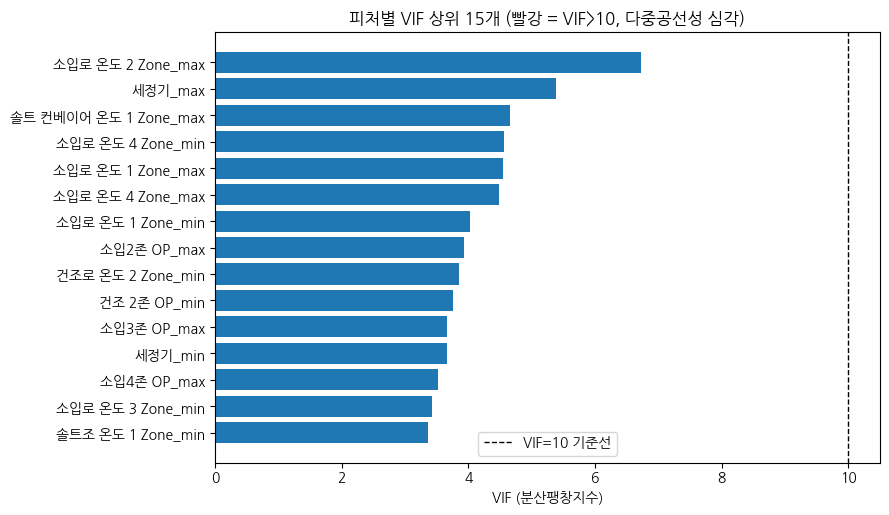

In [16]:
# ---- 7-1. VIF 상위 피처 시각화 ----
top_vif = vif_df.head(15).iloc[::-1]  # barh는 아래부터 그려지므로 순서 뒤집기
colors = ["#d62728" if v else "#1f77b4" for v in top_vif["is_high_vif"]]

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top_vif))))
ax.barh(top_vif["feature"], top_vif["VIF"], color=colors)
ax.axvline(10, color="black", linestyle="--", linewidth=1, label="VIF=10 기준선")
ax.set_xlabel("VIF (분산팽창지수)")
ax.set_title("피처별 VIF 상위 15개 (빨강 = VIF>10, 다중공선성 심각)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "24_vif_top_features.png"), dpi=150)
plt.show()

## 8. 최종 Test 비교 (Test 세트는 이 섹션에서 새 모델에 한해 단 한 번만 사용)

03의 7개 모델(LinearRegression, SGDRegressor, Ridge, Lasso, DecisionTree, RandomForest,
GradientBoosting)의 Test 성능은 **이미 03에서 계산되어 저장된
`model_comparison_test_metrics.csv`를 그대로 재사용**합니다 (다시 예측/평가하지 않음 —
이미 확정된 값이므로 Test를 다시 여는 것이 아닙니다). 이 노트북에서 새로 학습한 모델들
(튜닝된 RandomForest, Lasso 피처 서브셋 Ridge/RandomForest, XGBoost, LightGBM)에 대해서만
Test 세트를 **이 셀에서 처음이자 마지막으로 한 번** 사용해 평가합니다.

In [17]:
# ---- 8. Test 세트 transform (04에서 처음 여는 시점) ----
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
X_test_sub = X_test_scaled[lasso_selected_features]

new_models_for_test = {
    f"RandomForest_tuned(depth={rf_tuned_best_depth})": (rf_tuned_model, X_test_scaled),
    "Ridge_lasso_subset": (ridge_subset_model, X_test_sub),
    "RandomForest_lasso_subset": (rf_subset_model, X_test_sub),
    "XGBoost": (xgb_model, X_test_scaled),
    "LightGBM": (lgb_model, X_test_scaled),
}

new_test_rows = []
for name, (model, X_te) in new_models_for_test.items():
    metrics = tu.evaluate_regression(y_test, model.predict(X_te))
    new_test_rows.append({"model": name, "split": "test", **metrics})

new_test_df = pd.DataFrame(new_test_rows)
old_test_df = pd.read_csv(os.path.join(DATA_DIR, "model_comparison_test_metrics.csv"))

test_metrics_v2 = pd.concat([old_test_df, new_test_df], ignore_index=True)
test_metrics_v2 = test_metrics_v2.sort_values("R2", ascending=False).reset_index(drop=True)
test_metrics_v2.to_csv(os.path.join(DATA_DIR, "model_comparison_test_metrics_v2.csv"), index=False)

test_metrics_v2

,model,split,R2,RMSE,MAE
0,Lasso,test,0.118647,0.051039,0.032820
1,Ridge_lasso_subset,test,0.070598,0.052412,0.033521
2,RandomForest_lasso_subset,test,0.063698,0.052606,0.033635
3,Ridge,test,0.036803,0.053356,0.033297
4,SGDRegressor,test,0.030485,0.053531,0.033224
5,XGBoost,test,0.003900,0.054260,0.035204
6,LinearRegression,test,0.003645,0.054267,0.034597
7,GradientBoosting,test,-0.001445,0.054405,0.033265
8,DecisionTree,test,-0.132925,0.057867,0.034362
9,LightGBM,test,-0.165956,0.058704,0.038962


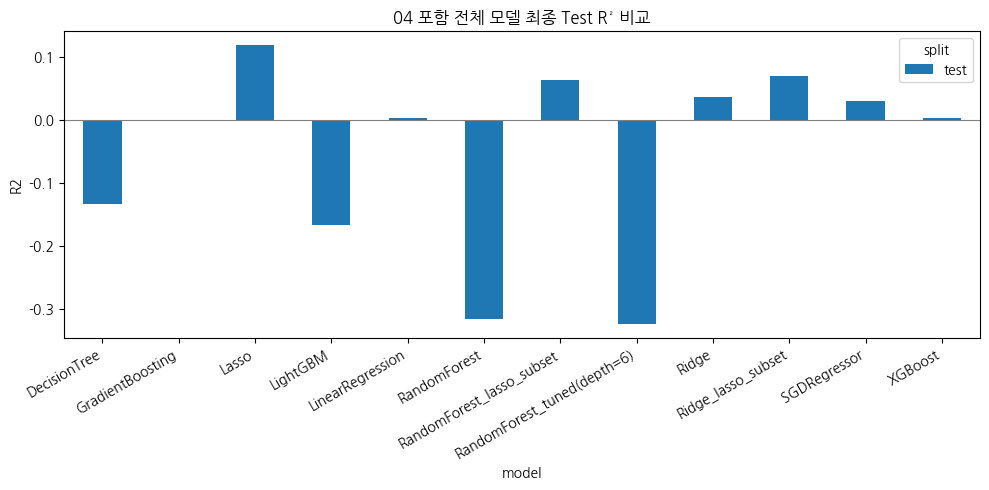

[최종 1위] Lasso: Test R2=0.1186, RMSE=0.0510, MAE=0.0328
(참고: 01 베이스라인 SGDRegressor Test R2=0.0414, 03 최고 Lasso Test R2=0.1186)


In [18]:
# ---- 8-1. 전체 12개 모델 Test R2 비교 시각화 ----
fig = tu.plot_model_comparison(test_metrics_v2, metric="R2", title="04 포함 전체 모델 최종 Test R² 비교")
fig.savefig(os.path.join(FIGURE_DIR, "25_model_comparison_test_r2_v2.png"), dpi=150)
plt.show()

best_row = test_metrics_v2.iloc[0]
print(f"[최종 1위] {best_row['model']}: Test R2={best_row['R2']:.4f}, "
      f"RMSE={best_row['RMSE']:.4f}, MAE={best_row['MAE']:.4f}")
print(f"(참고: 01 베이스라인 SGDRegressor Test R2=0.0414, "
      f"03 최고 Lasso Test R2=0.1186)")

## 9. Ridge / Lasso / GradientBoosting 피처 중요도 PNG 저장 (03 보완)

03에서는 LinearRegression과 RandomForest의 피처 중요도만 PNG로 저장했고, Ridge/Lasso/
GradientBoosting은 노트북 셀 출력으로만 남아 있었습니다. 03이 저장해 둔 모델 파일을
불러와 세 모델의 피처 중요도를 파일로 저장합니다.

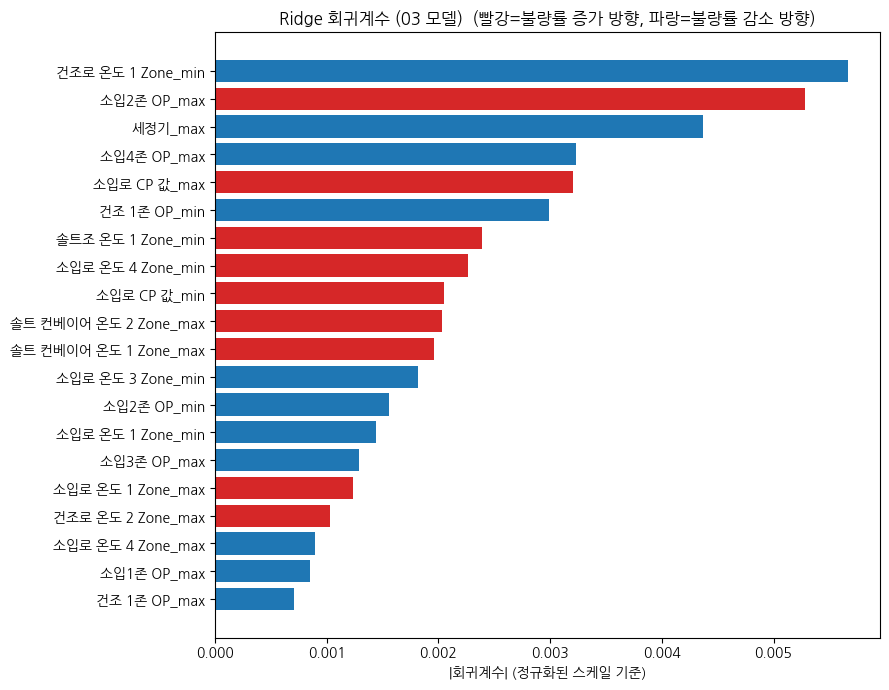

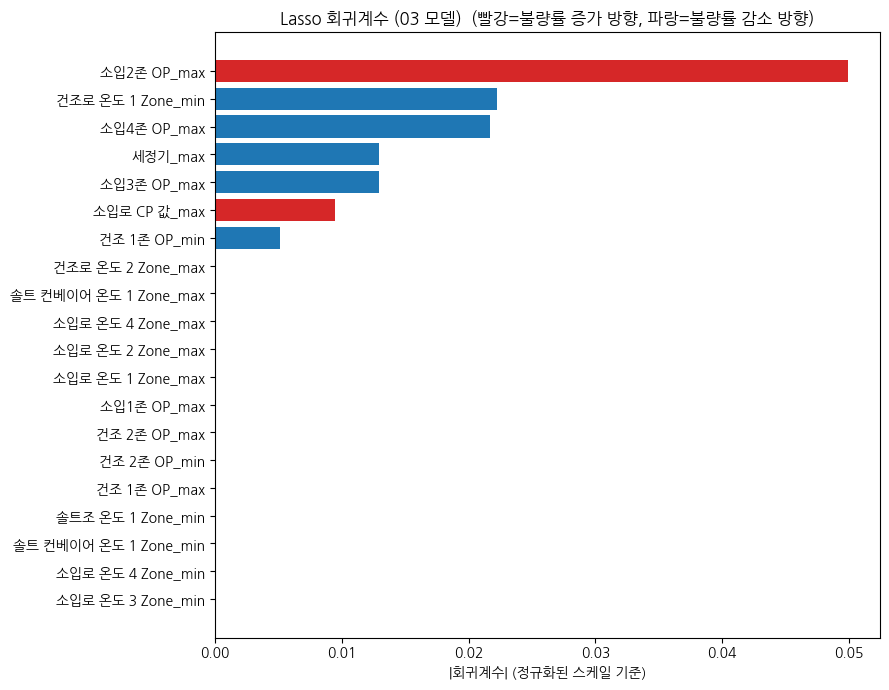

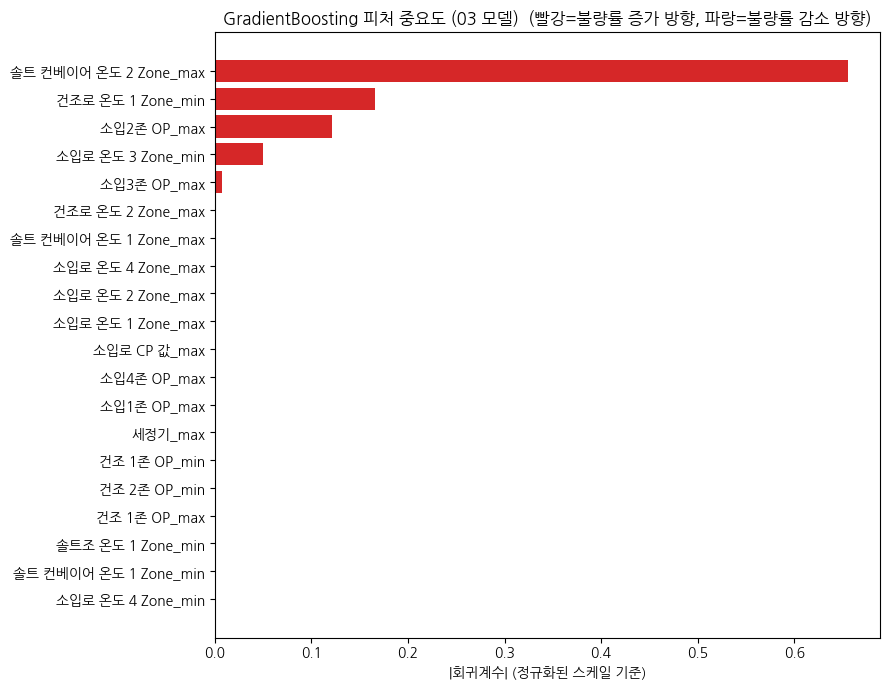

피처 중요도 PNG 3종 저장 완료: 26_ridge, 27_lasso, 28_gradient_boosting


In [19]:
# ---- 9. Ridge / Lasso / GradientBoosting 피처 중요도 저장 ----
gb_model_03 = joblib.load(os.path.join(CHECKPOINT_DIR, "gradient_boosting.joblib"))

fig = tu.plot_feature_importance(
    X_train_scaled.columns, ridge_model_03.coef_, top_n=20,
    title="Ridge 회귀계수 (03 모델)",
)
fig.savefig(os.path.join(FIGURE_DIR, "26_feature_importance_ridge.png"), dpi=150)
plt.show()

fig = tu.plot_feature_importance(
    X_train_scaled.columns, lasso_model_03.coef_, top_n=20,
    title="Lasso 회귀계수 (03 모델)",
)
fig.savefig(os.path.join(FIGURE_DIR, "27_feature_importance_lasso.png"), dpi=150)
plt.show()

fig = tu.plot_feature_importance(
    X_train_scaled.columns, gb_model_03.feature_importances_, top_n=20,
    title="GradientBoosting 피처 중요도 (03 모델)",
)
fig.savefig(os.path.join(FIGURE_DIR, "28_feature_importance_gradient_boosting.png"), dpi=150)
plt.show()

print("피처 중요도 PNG 3종 저장 완료: 26_ridge, 27_lasso, 28_gradient_boosting")

## 10. 산출물 저장 및 결론

In [20]:
# ---- 10. 새로 학습한 모델들 저장 ----
joblib.dump(rf_tuned_model, os.path.join(CHECKPOINT_DIR, "random_forest_tuned.joblib"))
joblib.dump(ridge_subset_model, os.path.join(CHECKPOINT_DIR, "ridge_lasso_subset.joblib"))
joblib.dump(rf_subset_model, os.path.join(CHECKPOINT_DIR, "rf_lasso_subset.joblib"))
joblib.dump(xgb_model, os.path.join(CHECKPOINT_DIR, "xgboost.joblib"))
joblib.dump(lgb_model, os.path.join(CHECKPOINT_DIR, "lightgbm.joblib"))

with open(os.path.join(DATA_DIR, "lasso_selected_features.json"), "w", encoding="utf-8") as f:
    json.dump(lasso_selected_features, f, ensure_ascii=False, indent=2)

print("체크포인트 5개 + lasso_selected_features.json 저장 완료.")
print("\n=== 04 노트북 최종 요약 ===")
print(test_metrics_v2[["model", "R2", "RMSE", "MAE"]].to_string(index=False))

체크포인트 5개 + lasso_selected_features.json 저장 완료.

=== 04 노트북 최종 요약 ===
                      model        R2     RMSE      MAE
                      Lasso  0.118647 0.051039 0.032820
         Ridge_lasso_subset  0.070598 0.052412 0.033521
  RandomForest_lasso_subset  0.063698 0.052606 0.033635
                      Ridge  0.036803 0.053356 0.033297
               SGDRegressor  0.030485 0.053531 0.033224
                    XGBoost  0.003900 0.054260 0.035204
           LinearRegression  0.003645 0.054267 0.034597
           GradientBoosting -0.001445 0.054405 0.033265
               DecisionTree -0.132925 0.057867 0.034362
                   LightGBM -0.165956 0.058704 0.038962
               RandomForest -0.315009 0.062344 0.041341
RandomForest_tuned(depth=6) -0.323466 0.062544 0.041259


### 결론

- **RandomForest `max_depth` 튜닝**으로 03의 심각한 과적합(Test R²=-0.3150)이 개선되었는지
  위 표로 확인할 수 있습니다.
- **Lasso 선택 피처만 사용**했을 때 전체 피처 대비 성능이 유지/개선되는지는 섹션 3의
  Val R2 비교, 섹션 8의 Test 표에서 확인합니다.
- **XGBoost/LightGBM**이 03의 GradientBoosting보다 부스팅의 이점을 더 살렸는지는 섹션 4·5의
  학습곡선(2번째 트리 이후에도 Val 손실이 계속 감소하는지)과 섹션 8의 Test 순위로 판단합니다.
- **K-Fold 안정성 검증**(섹션 6)에서 `kfold_std_R2`가 큰 모델은 Val 14건 기준 성능이
  우연에 가까울 수 있다는 뜻이므로, Test 순위와 함께 참고해야 합니다.
- **VIF 재점검**(섹션 7)에서 VIF>10인 피처 수와 최댓값을 통해, 02의 pairwise 상관계수
  제거만으로 해소되지 않은 다중공선성이 실제로 남아있는지 확인했습니다.

다음 실행 후 실제 수치를 반영해 **2차 보고서**(1차 보고서에 이어 이 6가지 개선 결과를
정리한 문서)를 작성할 예정입니다.